# Supply Chain Analysis (Delay)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import math

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
os.chdir(r'C:\Users\AnuragS\OneDrive\cv_project\Supply Chain Analysis\data')
os.getcwd()

'C:\\Users\\AnuragS\\OneDrive\\cv_project\\Supply Chain Analysis\\data'

## Data Fetch

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
df.columns = (df.columns
              .str.replace(' ','_')
              .str.replace('(','')
              .str.replace(')','')
              .str.lower().str.strip()
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  object 
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  object 
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  object 
 9   customer_city                180519 non-null  object 
 10  customer_country             180519 non-null  object 
 11  customer_email               180519 non-null  object 
 12  customer_fname               180519 non-null  object 
 13 

In [6]:
df.duplicated().sum()

np.int64(0)

## Handle Null Values

In [7]:
df_null = pd.DataFrame({
    'col_names': df.columns,
    'total_rows': df.shape[0],
    'null_rows':df.isnull().sum().values
})

df_null['null_pct'] = round((df_null['null_rows']/df_null['total_rows'])*100,4)

df_null = df_null.sort_values('null_rows',ascending=False)
df_null[df_null['null_rows'] != 0]

,col_names,total_rows,null_rows,null_pct
46,product_description,180519,180519,100.0000
43,order_zipcode,180519,155679,86.2397
14,customer_lname,180519,8,0.0044
19,customer_zipcode,180519,3,0.0017


For our analysis product description is not required

## Data Cleaning

In [8]:
drop_cols = [
'benefit_per_order',
'customer_city',
'customer_email',
'customer_fname',
'customer_id',
'customer_lname',
'customer_password',
'customer_state',
'customer_street',
'customer_zipcode',
'department_id',
'latitude',
'longitude',
'market',
'order_city',
'order_country',
'order_customer_id',
'order_id',
'order_item_cardprod_id',
'order_item_discount',
'order_item_discount_rate',
'order_item_id',
'order_item_product_price',
'order_item_quantity',
'order_item_total',
'order_state',
'product_card_id',
'product_category_id',
'product_description',
'product_image',
'product_status',
'order_zipcode'                 
]

all_cols = list(df.columns)
req_col = [col for col in all_cols if col not in drop_cols]
req_col

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_country',
 'customer_segment',
 'department_name',
 'order_date_dateorders',
 'order_item_profit_ratio',
 'sales',
 'order_profit_per_order',
 'order_region',
 'order_status',
 'product_name',
 'product_price',
 'shipping_date_dateorders',
 'shipping_mode']

In [9]:
df2 = df[req_col]
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


Need to filter out cancelled orders

In [10]:
df2['delivery_status'].value_counts(normalize=True)

delivery_status
Late delivery        0.548291
Advance shipping     0.230402
Shipping on time     0.178352
Shipping canceled    0.042954
Name: proportion, dtype: float64

In [11]:
df2 = df2[df2['delivery_status'] != 'Shipping canceled']
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [12]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         172765 non-null  object 
 1   days_for_shipping_real       172765 non-null  int64  
 2   days_for_shipment_scheduled  172765 non-null  int64  
 3   sales_per_customer           172765 non-null  float64
 4   delivery_status              172765 non-null  object 
 5   late_delivery_risk           172765 non-null  int64  
 6   category_id                  172765 non-null  int64  
 7   category_name                172765 non-null  object 
 8   customer_country             172765 non-null  object 
 9   customer_segment             172765 non-null  object 
 10  department_name              172765 non-null  object 
 11  order_date_dateorders        172765 non-null  object 
 12  order_item_profit_ratio      172765 non-null  float64
 13  sale

In [13]:
date_cols = [col for col in df2.columns if 'date' in col]
date_cols

['order_date_dateorders', 'shipping_date_dateorders']

In [14]:
df2['order_date_dateorders'] = pd.to_datetime(df2['order_date_dateorders'])
df2['shipping_date_dateorders'] = pd.to_datetime(df2['shipping_date_dateorders'])

In [15]:
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [16]:
df2.shape

(172765, 21)

In [17]:
df2.isnull().sum()

type                           0
days_for_shipping_real         0
days_for_shipment_scheduled    0
sales_per_customer             0
delivery_status                0
late_delivery_risk             0
category_id                    0
category_name                  0
customer_country               0
customer_segment               0
department_name                0
order_date_dateorders          0
order_item_profit_ratio        0
sales                          0
order_profit_per_order         0
order_region                   0
order_status                   0
product_name                   0
product_price                  0
shipping_date_dateorders       0
shipping_mode                  0
dtype: int64

## Check Categories

In [19]:
##cat_cols = list(df2.select_dtypes(include='str').columns)
for col in df2.columns:
    if df2[col].nunique() < 10:
        print(f'---{col}---')
        print(f'No. of Unique values = {df2[col].nunique()}')
        print(df2[col].value_counts())
        print(' ')

---type---
No. of Unique values = 4
type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
 
---days_for_shipping_real---
No. of Unique values = 7
days_for_shipping_real
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64
 
---days_for_shipment_scheduled---
No. of Unique values = 4
days_for_shipment_scheduled
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64
 
---delivery_status---
No. of Unique values = 3
delivery_status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64
 
---late_delivery_risk---
No. of Unique values = 2
late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64
 
---customer_country---
No. of Unique values = 2
customer_country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64
 
---customer_segment---
No. of Unique values = 3
customer_segment
Consumer       89420
Cor

In [20]:
df2['order_precessing_time'] = (df2['shipping_date_dateorders'] - df2['order_date_dateorders']).dt.days 

df2['delay'] = df2['order_precessing_time'] -df2['days_for_shipment_scheduled']

df2['is_delayed'] = np.where(df2['delay'] > 0,1,0)

df2['order_day'] = df2['order_date_dateorders'].dt.day_name()
df2['order_month'] = df2['order_date_dateorders'].dt.month 
df2['order_hour'] = df2['order_date_dateorders'].dt.hour

df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,product_name,product_price,shipping_date_dateorders,shipping_mode,order_precessing_time,delay,is_delayed,order_day,order_month,order_hour
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,0,Wednesday,1,22
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,1,Saturday,1,12
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,0,Saturday,1,12
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,0,Saturday,1,11
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,0,Saturday,1,11


In [21]:
df2.describe().T

,count,mean,min,25%,50%,75%,max,std
days_for_shipping_real,172765.0,3.498596,0.0,2.0,3.0,5.0,6.0,1.623446
days_for_shipment_scheduled,172765.0,2.9331,0.0,2.0,4.0,4.0,4.0,1.373405
sales_per_customer,172765.0,183.165948,7.49,104.379997,163.990005,247.399994,1939.98999,120.141871
late_delivery_risk,172765.0,0.5729,0.0,0.0,1.0,1.0,1.0,0.494659
category_id,172765.0,31.856065,2.0,18.0,29.0,45.0,76.0,15.642216
order_date_dateorders,172765,2016-06-12 15:25:39.457991936,2015-01-01 00:00:00,2015-09-21 18:01:00,2016-06-11 08:11:00,2017-02-28 21:08:00,2018-01-31 23:38:00,NaN
order_item_profit_ratio,172765.0,0.120801,-2.75,0.08,0.27,0.36,0.5,0.46661
sales,172765.0,203.828493,9.99,119.980003,199.919998,299.950012,1999.98999,132.39252
order_profit_per_order,172765.0,22.03236,-4274.97998,7.03,31.52,64.800003,911.799988,104.355313
product_price,172765.0,141.278595,9.99,50.0,59.990002,199.990005,1999.98999,139.862956


In [22]:
print('--- Is Delayed ---')
print(f'{df2.is_delayed.value_counts()}')
print(' ')
print('--- late delivery risk ---')
print(f'{df2.late_delivery_risk.value_counts()}')

--- Is Delayed ---
is_delayed
1    94523
0    78242
Name: count, dtype: int64
 
--- late delivery risk ---
late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64


### Profit vs Break - Even vs Loss

In [23]:
df2['profit_tag'] = np.where(
    df2['order_profit_per_order'] > 0,'Profit',
    np.where(df2['order_profit_per_order'] < 0,'Loss','Break Even'))

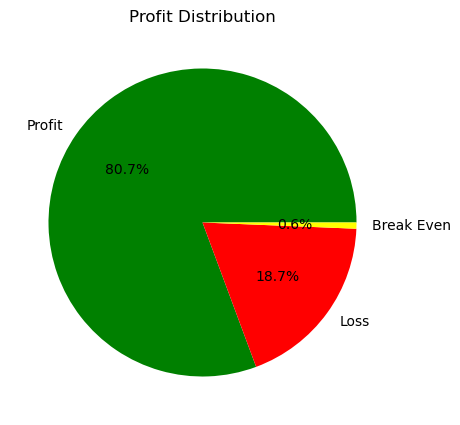

In [24]:
profit_cnt = df2['profit_tag'].value_counts(normalize=True)

color_map = {
    'Profit': 'green',
    'Loss': 'red',
    'Break Even': 'yellow'
}

colors = [color_map[label] for label in profit_cnt.index]


## Pie Chart
plt.figure(figsize=(5,5))
plt.pie(df2['profit_tag'].value_counts(normalize=True),
        labels= profit_cnt.index,
        autopct='%1.1f%%',
        colors=colors
        )
plt.title('Profit Distribution')
plt.show()

### Business KPIs

In [25]:
kpis = {}

# Total Orders
kpis['Total Orders'] = len(df2)

# Delayed orders
kpis['Delayed Orders'] = len(df2[df2['is_delayed'] == 1])

## ontime delivery
kpis['On time delivery'] = kpis['Total Orders'] - kpis['Delayed Orders']

# 90% of delayed orders were delivered within X days of the expected delivery date
kpis['90% Delay Days'] = int(df2[df2['is_delayed'] == 1]['delay'].quantile(0.9))

# On time delivery %
kpis['ontime delivery %'] = round((kpis['On time delivery']/kpis['Total Orders'])*100,2)

# Late Delivery % 
kpis['Late Delivery %'] = round((kpis['Delayed Orders']/kpis['Total Orders'])*100,2)

## Total profit
kpis['Total profit'] = float(round(df2.loc[df2['order_profit_per_order'] > 0, 'order_profit_per_order'].sum(),2))

## total loss due to delay
kpis['Total loss due to delay'] = float(round(df2.loc[df2['delay'] > 0, 'order_profit_per_order'].sum(),2))

print('\n--- Business KPIs ---\n')
for k,v in kpis.items():
    print(f'{k} = {v}')


--- Business KPIs ---

Total Orders = 172765
Delayed Orders = 94523
On time delivery = 78242
90% Delay Days = 3
ontime delivery % = 45.29
Late Delivery % = 54.71
Total profit = 7514813.81
Total loss due to delay = 2055765.16


## Profitability vs Delivery Time Analysis

In [26]:
df_profit_metric = (df2.groupby('delay')['order_profit_per_order']
                       .agg(
                           mean_profit = 'mean',
                           total_profit = 'sum',
                           no_of_orders = 'count'
                       )
                    .reset_index()
                   )

In [27]:
df_profit_metric

,delay,mean_profit,total_profit,no_of_orders
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [28]:
df_delay_dist = (
    df2['delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [29]:
df_delay_dist

,delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


1. Early shipment: 23%<br>
2. On time delivery: 21%<br>
3. 1 day delay: 31%
4. 2 more than days delay: 23%

In [30]:
def f_format_values(x):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'.replace('.0M', 'M')
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    return str(int(x))

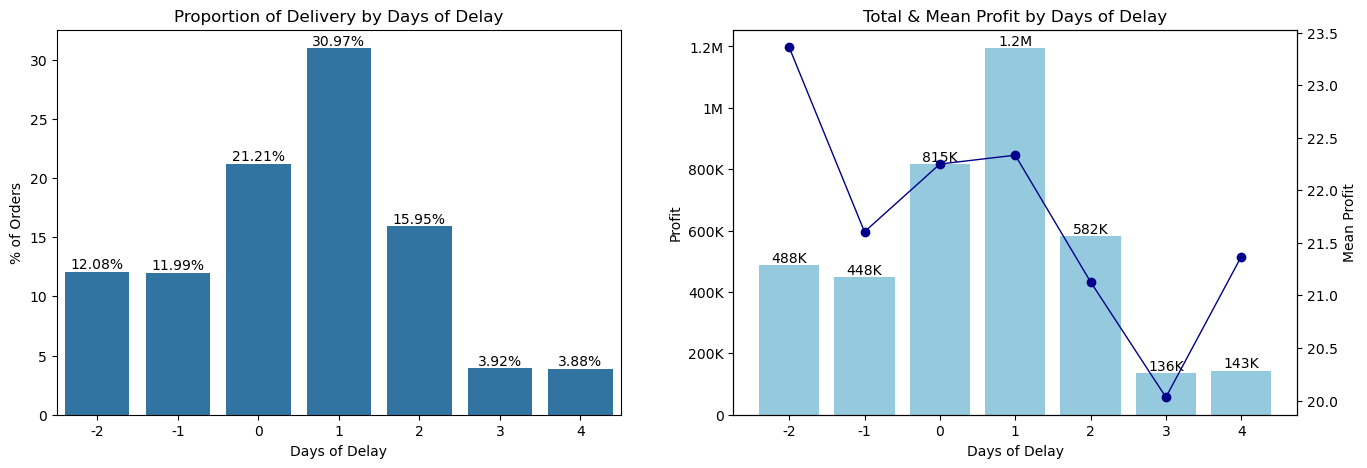

In [31]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

## Proportion of Deliveries by Delay Days
sns.barplot(data=df_delay_dist,x='delay',y='proportion',ax=ax[0])
ax[0].set_title('Proportion of Delivery by Days of Delay')
ax[0].set_xlabel('Days of Delay')
ax[0].set_ylabel('% of Orders')

for container in ax[0].containers:
    pcts = [f'{v:.2f}%' for v in container.datavalues]
    ax[0].bar_label(container,labels=pcts)


##
sns.barplot(data=df_profit_metric,x='delay',y='total_profit',color='skyblue',ax=ax[1])
ax[1].set_title('Total & Mean Profit by Days of Delay')
ax[1].set_xlabel('Days of Delay')
ax[1].set_ylabel('Profit')

# Y-axis formatting (primary)
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f_format_values(x)))


## Secondary Axis
ax1_twins = ax[1].twinx()
x_pos = range(len(df_profit_metric))
ax1_twins.plot(x_pos,df_profit_metric['mean_profit'],marker='o',color='darkblue',linewidth=1)
ax1_twins.set_xticks(x_pos)
ax1_twins.set_xticklabels(df_profit_metric['delay'])
ax1_twins.set_ylabel('Mean Profit')


# Bar Labels (center of bar)
for container in ax[1].containers:
    labels = [f_format_values(v) for v in container.datavalues]
    ax[1].bar_label(container,labels=labels)

#### Insights

* 1-day delayed deliveries account for the largest share of orders (31%), making it the most common delivery outcome and the primary driver of overall business volume.
* Total profit is highest for orders delivered 1 day late (1.2M), followed by on-time deliveries (815K), indicating that the most profitable segments are also the highest-volume segments.
* Average profit per order is highest for deliveries made 2 days early, suggesting that early deliveries may be associated with higher-value customers, products, or order types.
* Both total profit and average profit decline as delivery delays increase, with orders delayed by 3–4 days generating the lowest profits.
* The key operational opportunity is reducing the large 1-day delay bucket and minimizing 3+ day delays, which could improve customer satisfaction while preserving or increasing profitability.


### Bottlenecks

In [32]:
dims = [
    'category_name',
    'customer_segment',
    'shipping_mode',
    'department_name',
    'order_region',
    'order_status',
    'type'
]

result = []

for dim in dims:
    cat_df = (
        df2.groupby(dim)
           .agg(
               total_orders=('delay', 'count'),
               delayed_orders=('is_delayed', 'sum')
           )
           .reset_index()
    )

    cat_df['dimensions'] = dim
    cat_df = cat_df.rename(columns={dim: 'dimension_value'})

    result.append(cat_df)

df_cat_delay = pd.concat(result , ignore_index=True)
df_cat_delay['pct_delays'] = (df_cat_delay['delayed_orders']/df_cat_delay['total_orders'])*100
df_cat_delay = df_cat_delay[['dimensions','dimension_value','total_orders','delayed_orders','pct_delays']]
df_cat_delay

,dimensions,dimension_value,total_orders,delayed_orders,pct_delays
0,category_name,Accessories,1697,973,57.336476
1,category_name,As Seen on TV!,66,38,57.575758
2,category_name,Baby,198,94,47.474747
3,category_name,Baseball & Softball,607,334,55.024712
4,category_name,Basketball,64,37,57.812500
...,...,...,...,...,...
97,order_status,PROCESSING,21902,11953,54.574925
98,type,CASH,19616,10545,53.757137
99,type,DEBIT,69295,37890,54.679270
100,type,PAYMENT,41725,22958,55.022169


In [33]:
df_cat_delay[df_cat_delay['dimensions'] == 'type']

,dimensions,dimension_value,total_orders,delayed_orders,pct_delays
98,type,CASH,19616,10545,53.757137
99,type,DEBIT,69295,37890,54.679270
100,type,PAYMENT,41725,22958,55.022169
101,type,TRANSFER,42129,23130,54.902799


In [34]:
df_cat_delay[df_cat_delay['dimensions'] == 'shipping_mode']

,dimensions,dimension_value,total_orders,delayed_orders,pct_delays
53,shipping_mode,First Class,26513,26513,100.000000
54,shipping_mode,Same Day,9293,0,0.000000
55,shipping_mode,Second Class,33806,26987,79.829024
56,shipping_mode,Standard Class,103153,41023,39.769081


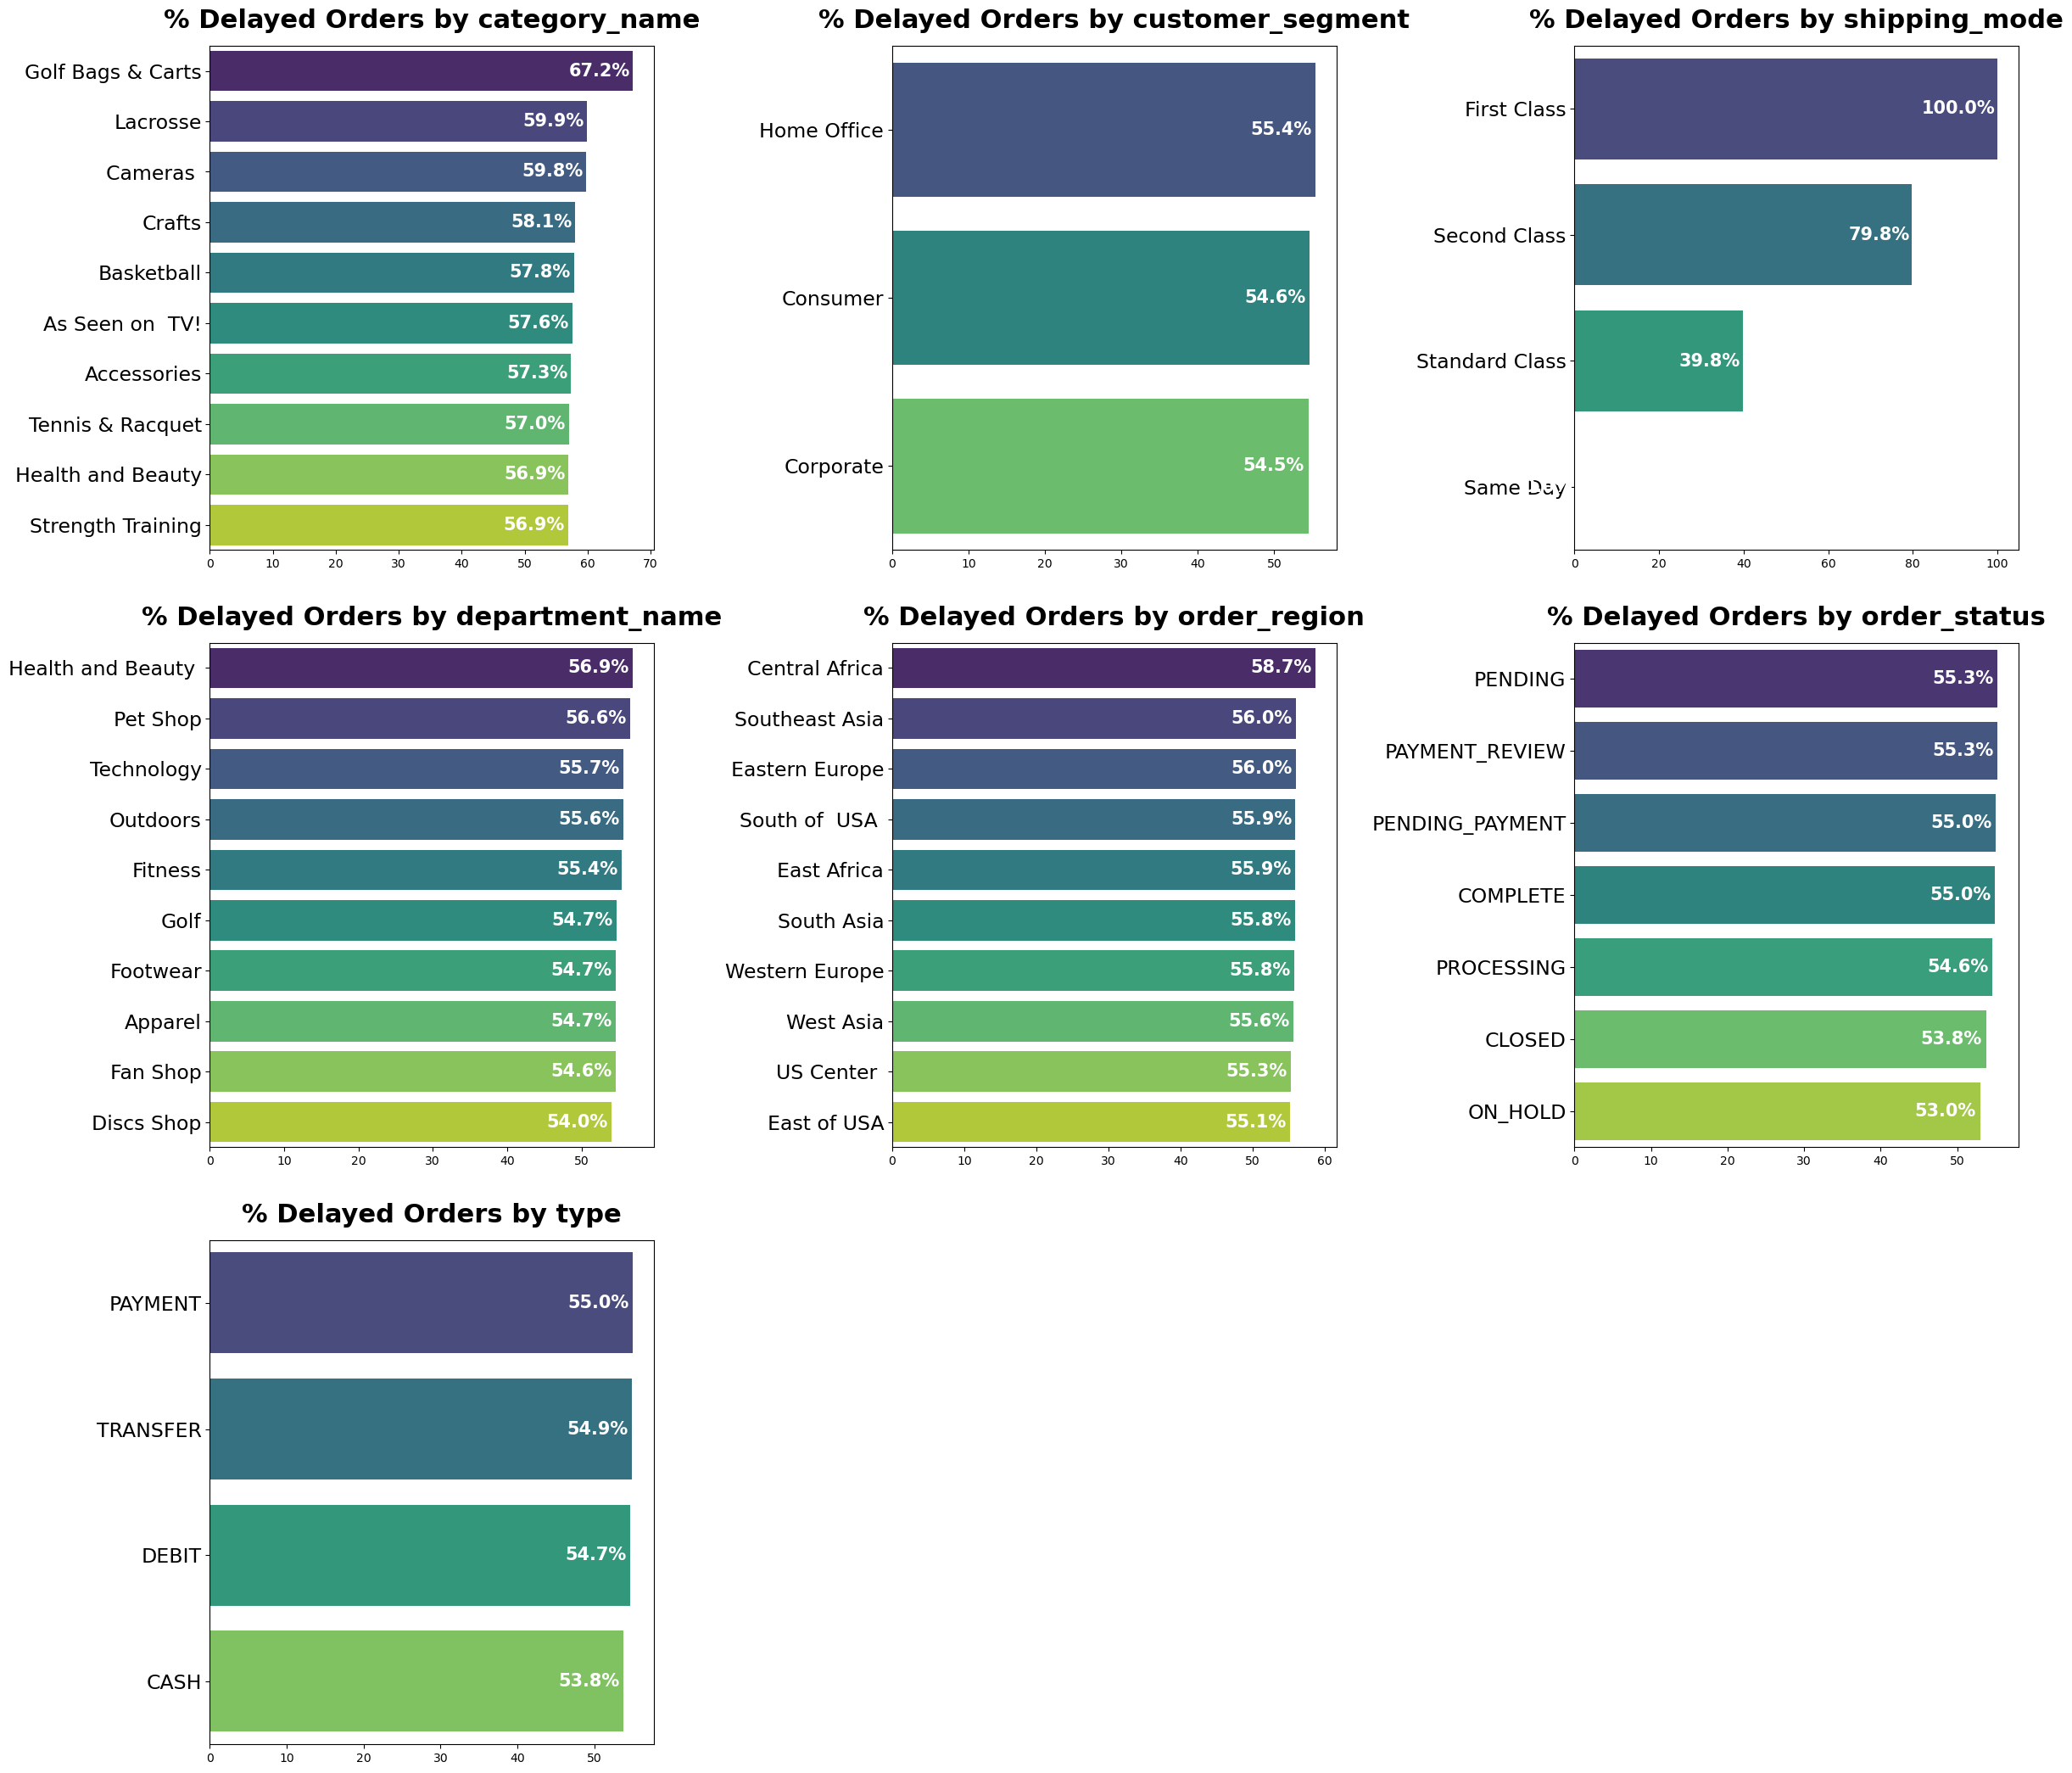

In [35]:
dims = [
'category_name',
'customer_segment',
'shipping_mode',
'department_name',
'order_region',
'order_status',
'type'
]

n_cols = 3
n_plot = len(dims)
n_rows = math.ceil(n_plot/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(24,7*n_rows),constrained_layout = True)

axes = axes.flatten()

for i, dim in enumerate(dims):
    df_plot = df_cat_delay[df_cat_delay['dimensions'] == dim].sort_values('pct_delays',ascending = False).head(10)
    sns.barplot(
        data = df_plot,
        x = 'pct_delays',
        y = 'dimension_value',
        hue='dimension_value',
        palette='viridis',
        ax = axes[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('',fontsize=14,fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=17)
    axes[i].set_title(f'% Delayed Orders by {dim}',fontsize=22,fontweight='bold',pad=15)
    for j, value in enumerate(df_plot['pct_delays']):
        axes[i].text(
            value - 0.5,
            j,
            f'{value:.1f}%',
            va='center',
            ha='right',
            color='white',
            fontsize=15,
            fontweight='bold'
        )

for j in range(len(dims),len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=3,wspace=1)


plt.tight_layout(h_pad=3,w_pad=3)
plt.show()

### Executive Interpretation

The analysis shows that **shipping mode is the primary contributor to order delays**, with First Class and Second Class shipments experiencing significantly higher delay rates than Standard Class. Additionally, certain product categories such as **Golf Bags & Carts, Lacrosse, and Cameras** consistently exhibit higher delays, indicating potential inventory, supplier, or fulfillment challenges. Other dimensions (customer segment, payment type, region, and department) show relatively minor variation and are unlikely to be major drivers of delays.

### Business Recommendations

* **Prioritize investigation of expedited shipping processes** to identify fulfillment and carrier bottlenecks.
* **Focus on high-delay product categories** by reviewing inventory availability, supplier lead times, and replenishment planning.
* **Improve inventory forecasting and fulfillment efficiency** for products with persistent delays.
* Since customer, payment, and regional factors have limited impact, operational and supply chain improvements should be the primary focus for reducing delays.


# Root Cause Analysis

In [36]:
drivers = [
    'customer_segment', #
    'shipping_mode', #
    'department_name', #
    'order_status', #
    'type' #
]

In [37]:
def f_top_drivers_for_region(_region):

    df_region = df2[df2['order_region'] == _region].copy()

    factors_all = []

    for fct in drivers:

        df_temp = (
            df_region.groupby(fct)
            .agg(
                total_orders=('delay', 'count'),
                late_orders=('is_delayed', 'sum'),
                avg_delay=('delay', 'mean')
            )
            .reset_index()
        )

        df_temp['delay_pct'] = (df_temp['late_orders'] / df_temp['total_orders'] * 100)
        df_temp['driver'] = fct

        # Works for both numeric and categorical columns
        df_temp['factor_level'] = (fct + ': ' + df_temp[fct].astype(str))

        factors_all.append(df_temp[['driver', 'factor_level', 'delay_pct','avg_delay', 'total_orders', 'late_orders']])

    # Combine all factors after loop
    df_final = pd.concat(factors_all, ignore_index=True)

    # Top 10 highest delay %
    top_fct = (df_final.sort_values('delay_pct', ascending=False).head(10))

    plt.figure(figsize=(10, 4))

    bars = plt.barh(
        top_fct['factor_level'],
        top_fct['delay_pct']
    )

    plt.xlabel('Delay %')
    plt.ylabel('Factors')
    plt.title(f'Top 10 Delay Drivers for {_region}')

    for bar in bars:
        w = bar.get_width()
        plt.text(
            w - 5,
            bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%',
            va='center',
            ha='center',
            color='white',
            fontsize=10
        )

    plt.gca().invert_yaxis()  # Highest value at top
    plt.tight_layout()
    plt.show()

    return top_fct

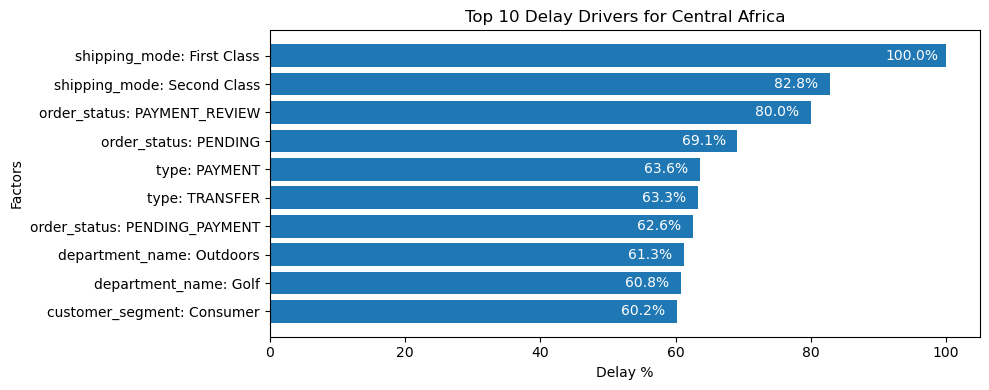

,driver,factor_level,delay_pct,avg_delay,total_orders,late_orders
3,shipping_mode,shipping_mode: First Class,100.000000,1.000000,278,278
5,shipping_mode,shipping_mode: Second Class,82.817869,2.127148,291,241
16,order_status,order_status: PAYMENT_REVIEW,80.000000,1.200000,20,16
17,order_status,order_status: PENDING,69.148936,0.574468,188,130
22,type,type: PAYMENT,63.583815,0.763006,346,220
23,type,type: TRANSFER,63.260341,0.608273,411,260
18,order_status,order_status: PENDING_PAYMENT,62.576687,0.736196,326,204
12,department_name,department_name: Outdoors,61.250000,0.800000,80,49
11,department_name,department_name: Golf,60.830861,0.673591,337,205
0,customer_segment,customer_segment: Consumer,60.150376,0.642857,798,480


In [38]:
f_top_drivers_for_region('Central Africa')

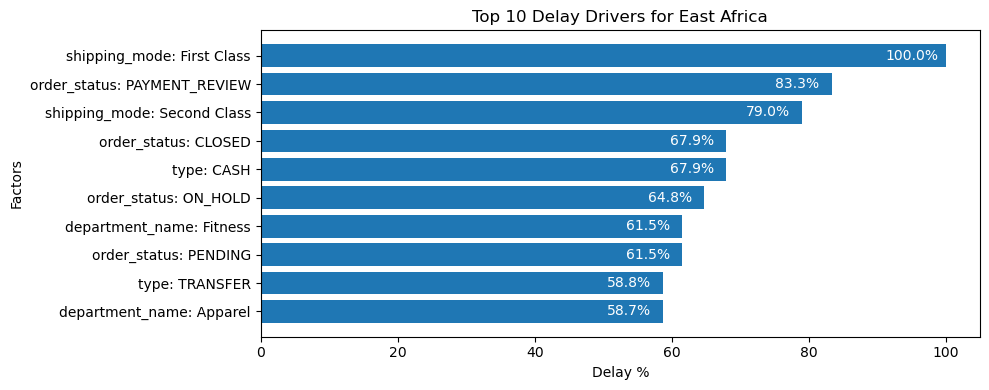

,driver,factor_level,delay_pct,avg_delay,total_orders,late_orders
3,shipping_mode,shipping_mode: First Class,100.000000,1.000000,277,277
16,order_status,order_status: PAYMENT_REVIEW,83.333333,1.000000,18,15
5,shipping_mode,shipping_mode: Second Class,79.036827,1.934844,353,279
13,order_status,order_status: CLOSED,67.924528,0.880503,159,108
20,type,type: CASH,67.924528,0.880503,159,108
15,order_status,order_status: ON_HOLD,64.761905,0.742857,105,68
9,department_name,department_name: Fitness,61.538462,0.923077,13,8
17,order_status,order_status: PENDING,61.502347,0.676056,213,131
23,type,type: TRANSFER,58.752998,0.621103,417,245
7,department_name,department_name: Apparel,58.730159,0.611111,504,296


In [39]:
f_top_drivers_for_region('East Africa')

## Time Based Analysis

In [40]:
max_shipping_date = df2['shipping_date_dateorders'].max()
min_shipping_date = df2['shipping_date_dateorders'].min()

print('Shipping Date Range')
print(f'Max Shipping Date: {max_shipping_date}')
print(f'Min Shipping Date: {min_shipping_date}')

Shipping Date Range
Max Shipping Date: 2018-02-06 22:14:00
Min Shipping Date: 2015-01-03 00:00:00


In [41]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   type                         172765 non-null  object        
 1   days_for_shipping_real       172765 non-null  int64         
 2   days_for_shipment_scheduled  172765 non-null  int64         
 3   sales_per_customer           172765 non-null  float64       
 4   delivery_status              172765 non-null  object        
 5   late_delivery_risk           172765 non-null  int64         
 6   category_id                  172765 non-null  int64         
 7   category_name                172765 non-null  object        
 8   customer_country             172765 non-null  object        
 9   customer_segment             172765 non-null  object        
 10  department_name              172765 non-null  object        
 11  order_date_dateorders        17

In [42]:
time_series_cols = ['order_day','order_month','order_hour']

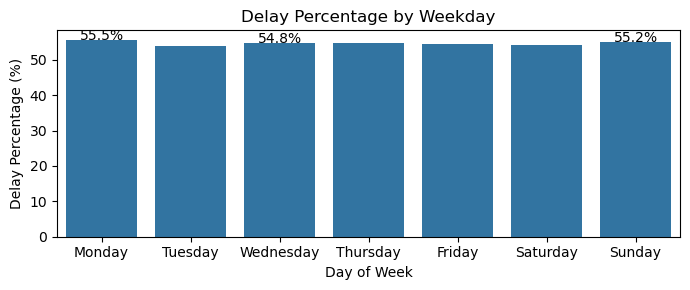

In [43]:
df_ts_delay_week = (
    df2.groupby('order_day')
        .agg(total_delay = ('is_delayed','sum'),
             delay_pct = ('is_delayed','mean')
            )
)

df_ts_delay_week['delay_pct'] = df_ts_delay_week['delay_pct'] * 100

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df_ts_delay_week = df_ts_delay_week.reindex(day_order)

plt.figure(figsize=(7,3))

sns.barplot(
    data=df_ts_delay_week,
    x=df_ts_delay_week.index,
    y='delay_pct'
)

top_3wd = df_ts_delay_week.nlargest(3, 'delay_pct')

for wd, row in top_3wd.iterrows():
    plt.text(
        x=wd,
        y=row['delay_pct'],
        s=f"{row['delay_pct']:.1f}%",  #f"{hour}:00\n{row['delay_pct']:.1f}%",
        ha='center'
    )

plt.title('Delay Percentage by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Delay Percentage (%)')

plt.tight_layout()
plt.show()

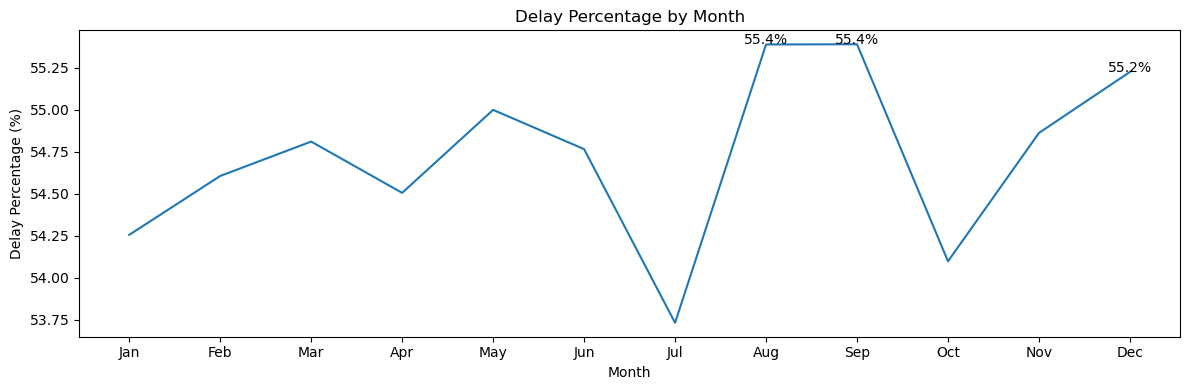

In [44]:
import calendar

df_ts_delay_month = (
    df2.groupby('order_month')
        .agg(total_delay = ('is_delayed','sum'),
             delay_pct = ('is_delayed','mean')
            )
)

df_ts_delay_month['delay_pct'] = df_ts_delay_month['delay_pct'] * 100

df_ts_delay_month.index = [calendar.month_abbr[i] for i in df_ts_delay_month.index]

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_ts_delay_month = df_ts_delay_month.reindex(month_order)

plt.figure(figsize=(12,4))

sns.lineplot(
    data=df_ts_delay_month,
    x=df_ts_delay_month.index,
    y='delay_pct'
)

top_3m = df_ts_delay_month.nlargest(3, 'delay_pct')

for month, row in top_3m.iterrows():
    plt.text(
        x=month,
        y=row['delay_pct'],
        s=f"{row['delay_pct']:.1f}%",  #f"{hour}:00\n{row['delay_pct']:.1f}%",
        ha='center'
    )

plt.title('Delay Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')

plt.tight_layout()
plt.show()

In [45]:
top_3m

,total_delay,delay_pct
Sep,8213,55.388454
Aug,8477,55.387128
Dec,6755,55.224003


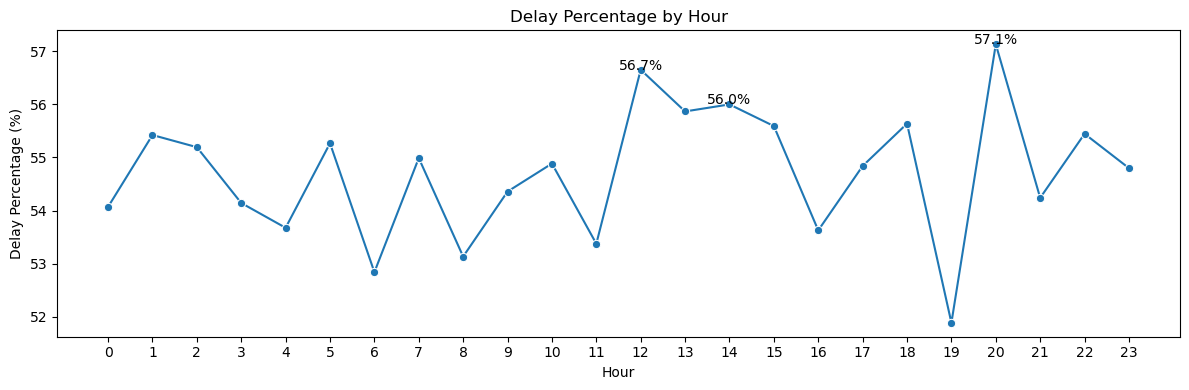

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate
df_ts_delay_hour = (
    df2.groupby('order_hour')
       .agg(
            total_delay=('is_delayed', 'sum'),
            delay_pct=('is_delayed', 'mean')
       )
       .sort_index()
)

# Convert percentage
df_ts_delay_hour['delay_pct'] *= 100

# Optional: ensure all hours exist
df_ts_delay_hour = df_ts_delay_hour.reindex(range(24), fill_value=0)

# Plot
plt.figure(figsize=(12,4))

sns.lineplot(
    data=df_ts_delay_hour,
    x=df_ts_delay_hour.index,
    y='delay_pct',
    marker='o'
)

# Show all hours
plt.xticks(range(24))

# -----------------------------
# Top 3 delay hours
# -----------------------------
top_3h = df_ts_delay_hour.nlargest(3, 'delay_pct')

# Add labels
for hour, row in top_3h.iterrows():
    plt.text(
        x=hour,
        y=row['delay_pct'],
        s=f"{row['delay_pct']:.1f}%",  #f"{hour}:00\n{row['delay_pct']:.1f}%",
        ha='center'
    )

plt.title('Delay Percentage by Hour')
plt.xlabel('Hour')
plt.ylabel('Delay Percentage (%)')

plt.tight_layout()
plt.show()

# Delay Analysis Summary Report

### Objective

Analyze delivery/order delays across **weekday, month, and hour** to identify patterns affecting operational efficiency and customer experience.

---

## Key Findings

### 1. Weekday Analysis

* Delay percentage remains almost constant across all weekdays (**~54–55.5%**).
* Very little variation observed between weekdays.

**Insight:**
Delays are **not driven by weekday-specific demand patterns** and indicate a consistent operational issue throughout the week.

**Business Action:**
Focus on improving **overall operational processes** instead of weekday-based interventions.

---

### 2. Monthly Analysis

* Delay percentage varies moderately across months (**~53.7% – 55.4%**).
* Highest delays observed in **August, September, and December**.
* Lowest delay observed in **July**.

**Insight:**
There is a **seasonal effect**, likely caused by increased demand during peak sales or holiday periods.

**Business Action:**
Implement **seasonal capacity planning** by increasing workforce, logistics capacity, and inventory planning before peak months.

---

### 3. Hourly Analysis

* Highest variation observed at hourly level (**~52% – 57%**).
* Peak delay periods: **12 PM – 2 PM** and **8 PM**.
* Lowest delay observed around **7 PM and early morning hours**.

**Insight:**
Hourly demand spikes create operational bottlenecks, making **time of day the strongest factor influencing delays**.

**Business Action:**
Increase staffing, dispatch frequency, and operational resources during peak hours.

---

## Factor Importance

| Factor  | Impact on Delay        | Priority |
| ------- | ---------------------- | -------- |
| Hour    | High (~5% variation)   | Highest  |
| Month   | Medium (~2% variation) | Medium   |
| Weekday | Low (~1% variation)    | Lowest   |

---

## Business Recommendations

* Optimize operations during **peak hours (12 PM – 3 PM, 7 PM – 9 PM)**.
* Prepare additional operational capacity during **August, September, and December**.
* Audit fulfillment and dispatch process to identify **system-wide inefficiencies**.
* Build a **predictive model** to forecast delay probability and proactively prevent SLA breaches.
* Improve customer communication during high-delay periods through proactive notifications.

---

## Final Conclusion

The business is experiencing a **consistently high delay rate (~55%)**, indicating systemic operational inefficiencies. While monthly seasonality has some impact, **hourly operational bottlenecks are the primary driver of delays**, making peak-hour optimization the highest priority for reducing delays and improving customer satisfaction.
